# Debug

## Debugging VibrationDataset

In [1]:
from src.data_processing.dataset import VibrationDatasetFromMap, VibrationMapBuilder

fold = "fold1"

builder = VibrationMapBuilder(data_dir=f"data/processed/bi/{fold}/train")
train_map, val_map = builder.get_split(val_ratio=0.2, stratify=True)
counter = {"B": 0, "I": 0}
for info in train_map:
    index, label, path = info["index"], info["label"], info["path"]
    # print(index, label, path)
    if label == "B":
        counter["B"] = 1+counter["B"]
    if label == "I":
        counter["I"] = 1+counter["I"]
print(f"Quantidade de dados de treino por classe: {counter}")

counter = {"B": 0, "I": 0}
for info in val_map:
    index, label, path = info["index"], info["label"], info["path"]
    # print(index, label, path)
    if label == "B":
        counter["B"] = 1+counter["B"]
    if label == "I":
        counter["I"] = 1+counter["I"]
print(f"Quantidade de dados de validação por classe: {counter}")

import os
counter = 0
for path in os.listdir("data/processed/bi/fold3/train"):
    # print(path)
    counter += 1

print(f"Totalizando: {counter} amostras.")
print(f"Quantidade de amostras de treino: {len(train_map)}")
print(f"Quantidade de amostras de validação: {len(val_map)}")

FileNotFoundError: [Errno 2] No such file or directory: 'data/processed/bi/fold1/train'

Caso queira utilizar o VibrationDatasetFromMap para test

In [ ]:
fold="fold2"
builder = VibrationMapBuilder(data_dir=f"data/processed/bi/{fold}/test")
test_map = builder.get_test_map()
print(f"Quantidade de amostras de teste: {len(test_map)}")

Quantidade de amostras de teste: 48


In [1]:
bearings_files_b7 = [(i, "B") for i in [122, 123, 124, 125]]
bearings_files_b14 = [(i, "B") for i in [189, 190, 191, 192]]
bearings_files_b21 = [(i, "B") for i in [226, 227, 228, 229]]
bearings_files_i7 = [(i, "I") for i in [109, 110, 111, 112]]
bearings_files_i14 = [(i, "I") for i in [174, 175, 176, 177]]
bearings_files_i21 = [(i, "I") for i in [213, 214, 215, 217]]

fold_files = {
    "fold1": {
        "train": bearings_files_b14 + bearings_files_b21 + bearings_files_i14 + bearings_files_i21,
        "test": bearings_files_b7 + bearings_files_i7
    },
    "fold2": {
        "train": bearings_files_b7 + bearings_files_b21 + bearings_files_i7 + bearings_files_i21,
        "test": bearings_files_b14 + bearings_files_i14
    },
    "fold3": {
        "train": bearings_files_b7 + bearings_files_b14 + bearings_files_i7 + bearings_files_i14,
        "test": bearings_files_b21 + bearings_files_i21
    }   
}

In [32]:
import numpy as np

data = np.load("data/processed/cwru_fft/bi/fold1/train/189_0.npy", allow_pickle=True)

data.item()['signal'].shape

(4800, 9600)

In [7]:
from src.models import CNN1D
print(CNN1D(input_length=4800, num_classes=2))

CNN1D(
  (conv1): Conv1d(1, 32, kernel_size=(16,), stride=(1,))
  (pool1): MaxPool1d(kernel_size=16, stride=16, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv1d(32, 32, kernel_size=(16,), stride=(1,))
  (pool2): MaxPool1d(kernel_size=16, stride=16, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=544, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=2, bias=True)
)


In [4]:
import numpy as np
import os
from scipy.io import loadmat
from src.data_processing.fft import fft_signal

segment_size = 9600
for fold, bearings_files in fold_files.items():
    output_dir = f"data/processed/cwru_fft/bi/{fold}/test"
    bearings = bearings_files["test"]
    os.makedirs(os.path.join(output_dir), exist_ok=True)
    counter = 0
    for basename, label in bearings:
        data = loadmat(f"data/raw/cwru/{basename}.mat")
        # print(data.keys())
        if basename == 174:
            basename = 173
        signal = data[f"X{basename}_DE_time"]
        # print(f"Original size of signal: {len(signal)}")
        maxsize_allowed_signal = int(len(signal) // segment_size) * segment_size
        # print(f"Max size of signal: {maxsize_allowed_signal}")
        signal = signal[:maxsize_allowed_signal]
        
        for i in range(0, len(signal), segment_size):
            seg = signal[i:i+segment_size]
            seg_fft = fft_signal(seg)
            output_path = f"{output_dir}/{basename}_{i//segment_size}"
            np.save(output_path, {"signal": seg_fft, "label": label})
            counter += 1

    print(f"Quantidade de segmentos salvos: {counter}")

Quantidade de segmentos salvos: 350
Quantidade de segmentos salvos: 320
Quantidade de segmentos salvos: 351


### UORED

### Processing and Saving Signal

In [ ]:
from datasets.uored import UORED

dataset = UORED()

bearings = dataset.load_data({"label": ["B", "I"], "condition_bearing_health": "faulty"})

import numpy as np
import os
from scipy.io import loadmat

segment_size = 9600
output_dir = "data/processed/uored/bi"
os.makedirs(os.path.join(output_dir), exist_ok=True)
counter = 0
for data in bearings:
    signal = data[0]
    label = data[1]
    basename = data[3]
    maxsize_allowed_signal = int(len(signal) // segment_size) * segment_size
    # print(f"Max size of signal: {maxsize_allowed_signal}")
    signal = signal[:maxsize_allowed_signal]
    
    for i in range(0, len(signal), segment_size):
        seg = signal[i:i+segment_size]
        output_path = f"{output_dir}/{basename}_{i//segment_size}"
        np.save(output_path, {"signal": seg, "label": label})
        counter += 1

print(f"Quantidade de segmentos salvos: {counter}")

Quantidade de segmentos salvos: 430


### Data Augmentation

#### Permutation

In [30]:
# debugging

import numpy as np

def permute_signal(signal, n_segments, seed=None):
    
    if seed is not None:
        np.random.seed(seed)

    if len(signal) % n_segments != 0:
        raise ValueError("Signal length must be divisible by n_segments.")
    
    segments = np.array_split(signal, n_segments)
    permuted_indices = np.random.permutation(n_segments)
    permuted_segments = [segments[i] for i in permuted_indices]
    permuted_signal = np.concatenate(permuted_segments)

    return permuted_signal


#### Mixing

In [17]:
import numpy as np

def mix_signals(signal1, signal2, n_segments=5, seed=None):
    if seed is not None:
        np.random.seed(seed)

    signal1 = np.array(signal1)
    signal2 = np.array(signal2)

    if len(signal1) != len(signal2):
        raise ValueError("Signals must have the same length.")

    if len(signal1) % n_segments != 0:
        raise ValueError("Signal length must be divisible by n_segments.")

    segment_length = len(signal1) // n_segments

    # Split signals into segments
    segs1 = np.array_split(signal1, n_segments)
    segs2 = np.array_split(signal2, n_segments)

    # Randomly choose a pattern: e.g., [0, 1, 0, 1, 0] means seg1, seg2, seg1...
    pattern = np.random.choice([0, 1], size=n_segments)

    mixed_segments = [
        segs1[i] if pattern[i] == 0 else segs2[i]
        for i in range(n_segments)
    ]

    # Concatenate segments to form the mixed signal
    mixed_signal = np.concatenate(mixed_segments)

    return mixed_signal


#### Applying data augmentation

In [29]:
import random
from datasets.uored import UORED

dataset = UORED()

bearings = dataset.load_data({"label": ["B", "I"], "condition_bearing_health": "faulty"})

import numpy as np
import os

segment_size = 9600
n_segments = 6
output_dir = "data/processed/uored/bi"
os.makedirs(os.path.join(output_dir), exist_ok=True)
counter = 0
for data in bearings:
    signal = data[0]
    label = data[1]
    basename = data[3]
    maxsize_allowed_signal = int(len(signal) // segment_size) * segment_size
    signal = signal[:maxsize_allowed_signal]
    segs = []
    for i in range(0, len(signal), segment_size):
        seg = signal[i:i+segment_size]
        if (i//segment_size) % 2 == 0:
            segs.append(seg)
            continue
        segs.append(seg)
        output_path = f"{output_dir}/da_{basename}_{i//segment_size}"
        if random.random() < 0.5:
            # seg_permuted = (seg, n_segments)
            seg_mixed = mix_signals(segs[0], segs[1], n_segments)   
            np.save(output_path, {"signal": seg_mixed, "label": label})
        segs = []
        counter += 1

print(f"Quantidade de segmentos salvos: {counter}")

Quantidade de segmentos salvos: 210


In [33]:
from datasets.uored import UORED

dataset = UORED()

bearings = dataset.load_data({"filename": "I_3_2", "label": ["B", "I"], "condition_bearing_health": "faulty"})
signal = None
for data in bearings:
    signal = data[0]
    label = data[1]
    basename = data[3]

In [38]:
from src.data_processing.fft import fft_signal

mag = fft_signal(signal[:9600])
mag.shape

(4800,)

(420000,)
FFT_magnitude: (210000,)


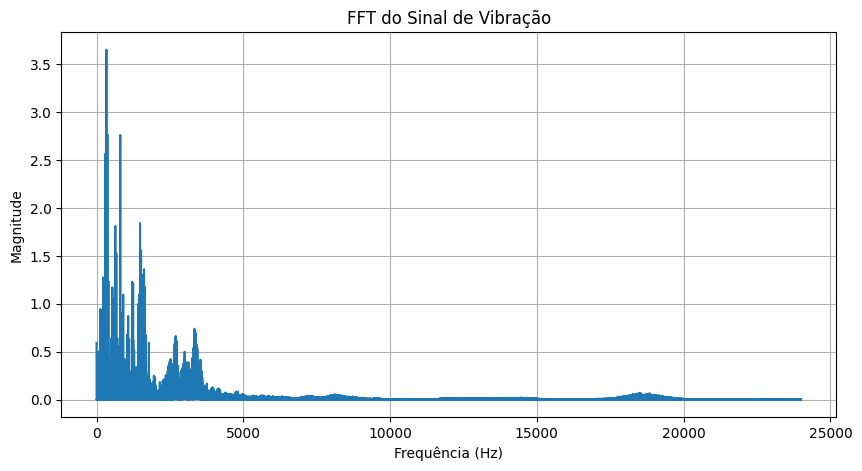

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import detrend, windows

def fft_signal(signal, fs=48000):
    t = np.linspace(0, 1, fs, endpoint=False)

    # Pre-processing
    signal = detrend(signal)  # remove tendência
    window = windows.hann(len(signal))  # aplica janela
    signal = signal * window

    # FFT
    N = len(signal)
    freq = np.fft.fftfreq(N, d=1/fs)
    fft_values = np.fft.fft(signal)

    # Positive frequencies and normalization
    mask = freq >= 0
    freq = freq[mask]
    fft_magnitude = np.abs(fft_values[mask]) * 2 / N
    print(f"FFT_magnitude: {fft_magnitude.shape}")
    # Plot
    plt.figure(figsize=(10, 5))
    plt.plot(freq, fft_magnitude)
    plt.title('FFT do Sinal de Vibração')
    plt.xlabel('Frequência (Hz)')
    plt.ylabel('Magnitude')
    plt.grid(True)
    plt.show()

print(signal.shape)
fft_signal(signal)

### Hust

In [1]:
import os
import numpy as np
from datasets.hust import Hust
from librosa import resample

dataset = Hust()

bearings = dataset.load_data({"label": ["B", "I"], "bearing_type": "6205"})


segment_size = 9600
output_dir = "data/processed/hust/bi"
os.makedirs(os.path.join(output_dir), exist_ok=True)
counter = 0
for data in bearings:
    signal = data[0]
    label = data[1]
    basename = data[3]

    signal_resampled = resample(signal, orig_sr=51200, target_sr=48000)

    maxsize_allowed_signal = int(len(signal_resampled) // segment_size) * segment_size
    signal_resampled = signal_resampled[:maxsize_allowed_signal]
    
    for i in range(0, len(signal_resampled), segment_size):
        seg = signal_resampled[i:i+segment_size]
        output_path = f"{output_dir}/{basename}_{i//segment_size}"
        np.save(output_path, {"signal": seg, "label": label})
        counter += 1

print(f"Quantidade de segmentos salvos: {counter}")

Quantidade de segmentos salvos: 300


In [8]:
import numpy as np

total_accuracy = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])

m1 = np.mean(np.mean(total_accuracy, axis=1))
soma = 0
qtd = 0
for i in total_accuracy:
    for j in i:
        soma += j
        qtd += 1
print(f"m1 -> {m1}")
print(f"soma -> {soma}")
print(f"qtd -> {qtd}")
print(f"média -> {soma/qtd}")

m1 -> 5.0
soma -> 45
qtd -> 9
média -> 5.0
